In [1]:
"""
Exercise 2.1 - Supervised Learning of the Value Function v(t, x)

We train a DGM-style neural network to approximate the LQR value function
    v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr
obtained analytically in Exercise 1.1.

Architecture : Net_DGM with hidden layer size 100 (as specified).
Training     : Adam optimiser minimising the mean-square error on randomly
               sampled (t, x) pairs drawn from [0,T] x [-3,3]^2.
Output       : Training loss curve saved to exercise_2_1_loss.png.
"""

import numpy as np
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------------------
# LQRSolver (copied from Ex 1.1 so this file runs standalone)
# -----------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via the Riccati ODE.

    Minimise J(t,x) = E[ int_t^T (X'CX + a'Da) ds + X_T' R X_T ]
    subject to  dX = (HX + Ma) dt + sigma dW,  X_t = x.

    Value function:
        v(t,x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr
    Optimal control:
        a*(t,x) = -D^{-1} M' S(t) x
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)
        self.d = self.H.shape[0]
        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T
        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        """
        RHS of the Riccati ODE in forward time tau = T - t.
        Original:  S'(t) = -2H'S + S M D^{-1} M' S - C,  S(T) = R.
        Flipped:   dS/dtau = 2H'S - S M D^{-1} M' S + C,  S(0) = R.
        """
        S = S_flat.reshape(self.d, self.d)
        dS = 2.0 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.reshape(-1)

    def solve_riccati(self, time_grid):
        """
        Solve the Riccati ODE on the given time grid and build interpolators
        for S(t) and the integral correction term.

        Args:
            time_grid : array-like of times in [0, T] (numpy or torch)

        Returns:
            S_values : ndarray of shape (len(time_grid), d, d)
        """
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.detach().cpu().numpy()
        time_grid = np.array(time_grid, dtype=float).reshape(-1)

        tau_grid = self.T - time_grid
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.reshape(-1),
            t_eval=tau_grid[::-1],
            method='RK45',
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        S_values = sol.y[:, ::-1].T.reshape(-1, self.d, self.d)
        S_values = 0.5 * (S_values + np.transpose(S_values, (0, 2, 1)))

        kind_S = 'cubic' if len(time_grid) >= 4 else 'linear'
        self.S_interp = [
            [
                interp1d(time_grid, S_values[:, i, j], kind=kind_S,
                         bounds_error=False, fill_value='extrapolate')
                for j in range(self.d)
            ]
            for i in range(self.d)
        ]

        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values], dtype=float)
        integral = np.zeros(len(time_grid), dtype=float)
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i + 1] - time_grid[i]
            integral[i] = integral[i + 1] + 0.5 * dt * (trace_vals[i] + trace_vals[i + 1])

        self.integral_interp = interp1d(
            time_grid, integral, kind='linear',
            bounds_error=False, fill_value='extrapolate',
        )
        return S_values

    def _get_S(self, t):
        """Evaluate S(t) for a vector of times. Accepts numpy or torch."""
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first.")
        is_torch = isinstance(t, torch.Tensor)
        t_np = t.detach().cpu().numpy() if is_torch else np.asarray(t, dtype=float)
        t_flat = t_np.reshape(-1)
        S_out = np.zeros((len(t_flat), self.d, self.d), dtype=float)
        for i in range(self.d):
            for j in range(self.d):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)
        if is_torch:
            return torch.as_tensor(S_out, dtype=t.dtype, device=t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Compute v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr.

        Args:
            t_batch : torch tensor, shape (batch_size,)
            x_batch : torch tensor, shape (batch_size, 1, d)

        Returns:
            v : torch tensor, shape (batch_size, 1)
        """
        S = self._get_S(t_batch)          # (batch, d, d)
        x = x_batch.squeeze(1)            # (batch, d)
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)
        integral_np = self.integral_interp(t_batch.detach().cpu().numpy())
        integral = torch.as_tensor(integral_np, dtype=t_batch.dtype, device=t_batch.device)
        return (xSx + integral).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Compute a*(t,x) = -D^{-1} M' S(t) x.

        Args:
            t_batch : torch tensor, shape (batch_size,)
            x_batch : torch tensor, shape (batch_size, 1, d)

        Returns:
            a : torch tensor, shape (batch_size, d)
        """
        S = self._get_S(t_batch)
        x = x_batch.squeeze(1)
        neg_DinvMT = torch.as_tensor(-self.D_inv @ self.M.T, dtype=t_batch.dtype, device=t_batch.device)
        Sx = (S @ x.unsqueeze(2)).squeeze(2)
        return (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)

In [3]:
# -----------------------------------------------------------------------
# Net_DGM  -  architecture from [1] - 
# -----------------------------------------------------------------------

class Net_DGM(nn.Module):
    """
    DGM-style network [Sirignano & Spiliopoulos 2018].

    Input  : (t, x) where t is a scalar and x in R^d  -> concatenated to R^{d+1}.
    Output : scalar  (value function approximation).

    Architecture:
        S^1  = sigma( W^1 z + b^1 )                   initial layer
        G^l  = sigma( U^g_l z + W^g_l S^{l-1} + b^g_l )
        Z^l  = sigma( U^z_l z + W^z_l S^{l-1} + b^z_l )     DGM cell
        R^l  = sigma( U^r_l z + W^r_l S^{l-1} + b^r_l )
        H^l  = (1 - G^l) * sigma( U^h_l z + W^h_l (S^{l-1} * R^l) + b^h_l )
               + Z^l * S^{l-1}
        S^L  = H^L  (output of last DGM layer)
        out  = W^f S^L + b^f                          output layer

    with a single DGM hidden layer of size `hidden_size` (= 100 per spec).
    """

    def __init__(self, input_dim, hidden_size, output_dim=1, num_dgm_layers=3):
        """
        Args:
            input_dim      : dimension of z = (t, x),  i.e. 1 + d.
            hidden_size    : width of each DGM hidden layer.
            output_dim     : 1 for value function.
            num_dgm_layers : number of DGM recurrent layers (default 3).
        """
        super().__init__()
        self.hidden_size = hidden_size
        self.num_dgm_layers = num_dgm_layers

        # initial dense layer  z -> S^1
        self.initial_layer = nn.Linear(input_dim, hidden_size)

        # DGM recurrent layers
        # each gate has a weight for z (input) and for S^{l-1} (hidden state)
        for l in range(num_dgm_layers):
            setattr(self, f'Ug_{l}', nn.Linear(input_dim, hidden_size, bias=False))
            setattr(self, f'Wg_{l}', nn.Linear(hidden_size, hidden_size))
            setattr(self, f'Uz_{l}', nn.Linear(input_dim, hidden_size, bias=False))
            setattr(self, f'Wz_{l}', nn.Linear(hidden_size, hidden_size))
            setattr(self, f'Ur_{l}', nn.Linear(input_dim, hidden_size, bias=False))
            setattr(self, f'Wr_{l}', nn.Linear(hidden_size, hidden_size))
            setattr(self, f'Uh_{l}', nn.Linear(input_dim, hidden_size, bias=False))
            setattr(self, f'Wh_{l}', nn.Linear(hidden_size, hidden_size))

        # output layer  S^L -> scalar
        self.output_layer = nn.Linear(hidden_size, output_dim)

    def forward(self, t, x):
        """
        Args:
            t : torch tensor, shape (batch,) or (batch, 1)
            x : torch tensor, shape (batch, d)

        Returns:
            out : torch tensor, shape (batch, output_dim)
        """
        if t.dim() == 1:
            t = t.unsqueeze(1)   # (batch, 1)

        # concatenate to get input z = (t, x)
        z = torch.cat([t, x], dim=1)          # (batch, 1+d)

        # initial layer
        S = torch.tanh(self.initial_layer(z))  # (batch, hidden)

        # DGM recurrent layers
        for l in range(self.num_dgm_layers):
            G = torch.sigmoid(getattr(self, f'Ug_{l}')(z) + getattr(self, f'Wg_{l}')(S))
            Z = torch.sigmoid(getattr(self, f'Uz_{l}')(z) + getattr(self, f'Wz_{l}')(S))
            R = torch.sigmoid(getattr(self, f'Ur_{l}')(z) + getattr(self, f'Wr_{l}')(S))
            H = torch.tanh(getattr(self, f'Uh_{l}')(z) + getattr(self, f'Wh_{l}')(S * R))
            S = (1.0 - G) * H + Z * S

        return self.output_layer(S)             # (batch, output_dim)

In [4]:
# -----------------------------------------------------------------------
# Problem setup  (same matrices as Exercise 1.1 / 1.2)
# -----------------------------------------------------------------------

H     = np.array([[0.5, 0.1], [0.1, 0.3]])
M     = np.array([[1.0, 0.5], [0.0, 1.0]])
C     = np.array([[2.0, 0.5], [0.5, 1.0]])
D     = np.array([[2.0, 0.0], [0.0, 1.0]])
R_mat = np.array([[1.0, 0.0], [0.0, 2.0]])
sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
T     = 1.0
d     = 2   # spatial dimension

# Solve Riccati ODE once on a fine grid
solver = LQRSolver(H, M, C, D, R_mat, sigma, T)
time_grid = np.linspace(0.0, T, 2000)
solver.solve_riccati(time_grid)
print("Riccati ODE solved on fine grid with 2000 points.")

Riccati ODE solved on fine grid with 2000 points.


In [5]:
# -----------------------------------------------------------------------
# Training
# -----------------------------------------------------------------------

torch.manual_seed(42)

# hyper-parameters
HIDDEN_SIZE  = 100
N_DATA       = 10_000   # training points per epoch
N_EPOCHS     = 3_000
LR           = 1e-3
LOG_EVERY    = 50       # print loss every this many epochs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# input dimension = 1 (time) + 2 (space) = 3
net = Net_DGM(input_dim=1 + d, hidden_size=HIDDEN_SIZE, output_dim=1).to(device)
optimiser = torch.optim.Adam(net.parameters(), lr=LR)

def sample_batch(n, t_low=0.0, t_high=T, x_low=-3.0, x_high=3.0):
    """
    Draw n i.i.d. points uniformly from [t_low, t_high] x [x_low, x_high]^2
    and return the analytical value function as the target.

    Returns:
        t_batch : (n,)     float32 on device
        x_batch : (n, d)   float32 on device
        v_batch : (n, 1)   float32 on device
    """
    t_np = np.random.uniform(t_low, t_high, size=(n,)).astype(np.float32)
    x_np = np.random.uniform(x_low, x_high, size=(n, d)).astype(np.float32)

    t_torch = torch.from_numpy(t_np)
    # value_function expects x_batch of shape (batch, 1, d)
    x_torch_lqr = torch.from_numpy(x_np).unsqueeze(1)

    with torch.no_grad():
        v_torch = solver.value_function(t_torch, x_torch_lqr)  # (n, 1)

    return (
        t_torch.to(device),
        torch.from_numpy(x_np).to(device),
        v_torch.to(device),
    )

loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    t_b, x_b, v_target = sample_batch(N_DATA)

    optimiser.zero_grad()
    v_pred = net(t_b, x_b)          # (n, 1)
    loss = torch.mean((v_pred - v_target) ** 2)
    loss.backward()
    optimiser.step()

    loss_history.append(loss.item())

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"Epoch {epoch:5d}/{N_EPOCHS}  |  MSE loss = {loss.item():.4e}")

print("\nTraining complete.")

Using device: cpu
Epoch     1/3000  |  MSE loss = 1.5362e+02
Epoch    50/3000  |  MSE loss = 2.6141e+01
Epoch   100/3000  |  MSE loss = 4.7222e+00
Epoch   150/3000  |  MSE loss = 1.3359e+00
Epoch   200/3000  |  MSE loss = 5.3079e-01
Epoch   250/3000  |  MSE loss = 2.6508e-01
Epoch   300/3000  |  MSE loss = 2.1206e-01
Epoch   350/3000  |  MSE loss = 1.3977e-01
Epoch   400/3000  |  MSE loss = 1.2513e-01
Epoch   450/3000  |  MSE loss = 1.0714e-01
Epoch   500/3000  |  MSE loss = 8.0308e-02
Epoch   550/3000  |  MSE loss = 7.9439e-02
Epoch   600/3000  |  MSE loss = 6.5542e-02
Epoch   650/3000  |  MSE loss = 5.3316e-02
Epoch   700/3000  |  MSE loss = 4.6751e-02
Epoch   750/3000  |  MSE loss = 3.6257e-02
Epoch   800/3000  |  MSE loss = 3.3150e-02
Epoch   850/3000  |  MSE loss = 1.9821e-02
Epoch   900/3000  |  MSE loss = 1.8058e-02
Epoch   950/3000  |  MSE loss = 2.3647e-02
Epoch  1000/3000  |  MSE loss = 1.3334e-02
Epoch  1050/3000  |  MSE loss = 1.2728e-02
Epoch  1100/3000  |  MSE loss = 9.90

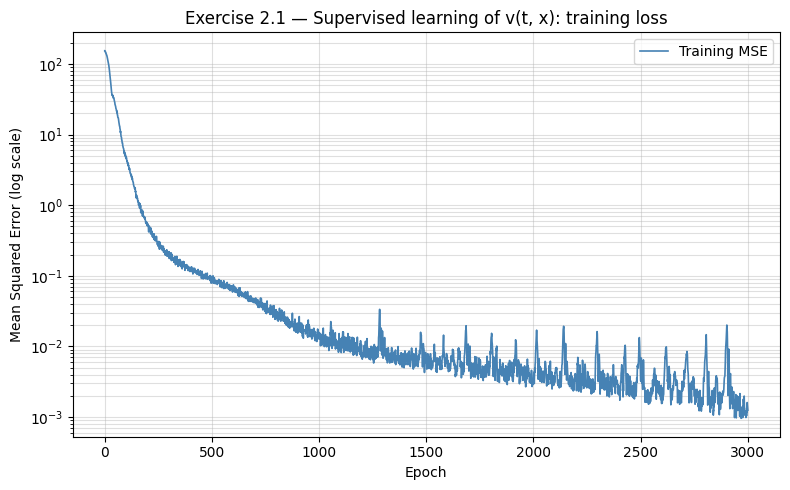

Saved exercise_2_1_loss.png


In [6]:
# -----------------------------------------------------------------------
# Plot training loss
# -----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(np.arange(1, N_EPOCHS + 1), loss_history, linewidth=1.2, color='steelblue', label='Training MSE')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean Squared Error (log scale)')
ax.set_title('Exercise 2.1 — Supervised learning of v(t, x): training loss')
ax.legend()
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('exercise_2_1_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exercise_2_1_loss.png')

<>:40: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
<>:40: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
C:\Users\M\AppData\Local\Temp\ipykernel_17568\1768257830.py:40: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  ax_nn.set_title(f'Net\_DGM  v̂(t={t_val}, x)')


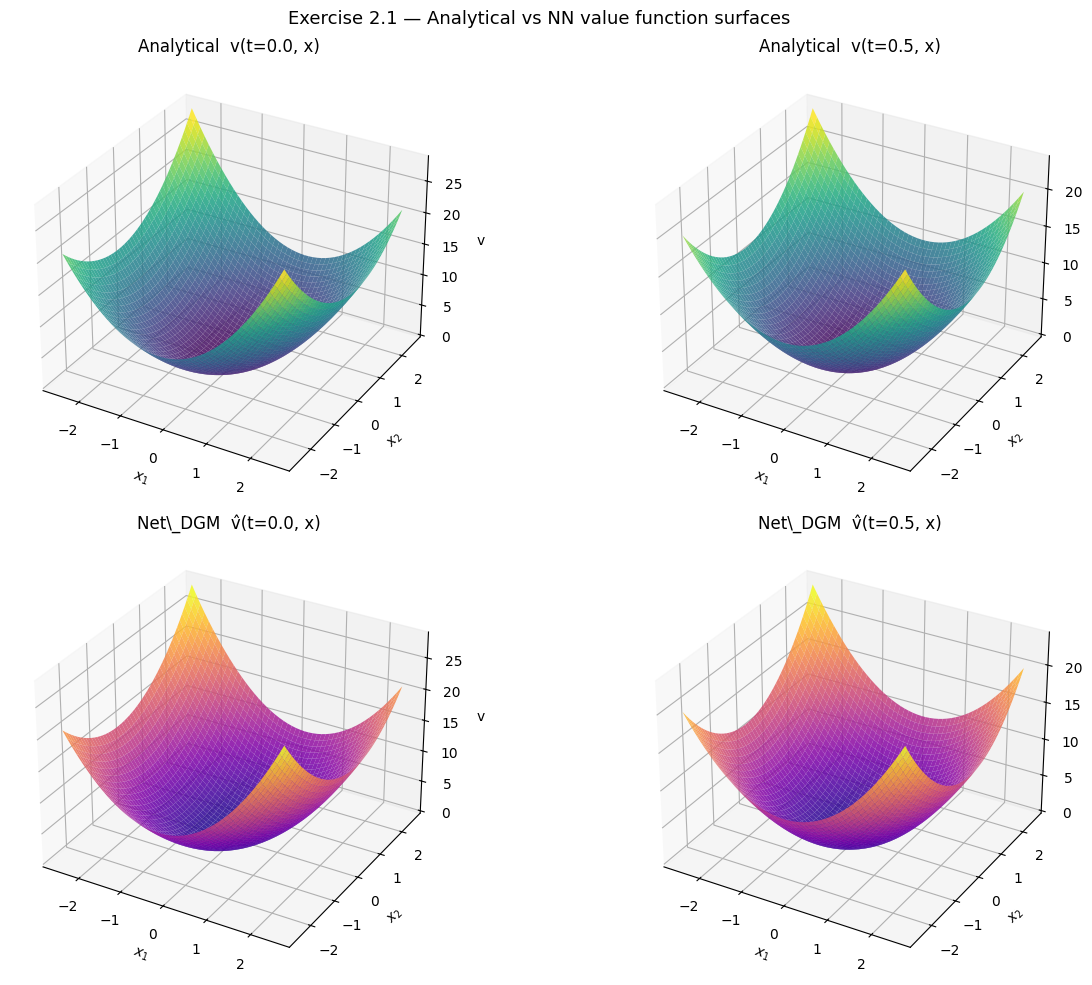

Saved exercise_2_1_surfaces.png


In [7]:
# -----------------------------------------------------------------------
# Visual sanity check: NN surface vs analytical surface at t = 0 and t = 0.5
# -----------------------------------------------------------------------

net.eval()

x_range = np.linspace(-2.5, 2.5, 50)
X1, X2 = np.meshgrid(x_range, x_range)
x_flat = torch.tensor(
    np.stack([X1.ravel(), X2.ravel()], axis=1), dtype=torch.float32
).to(device)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw={'projection': '3d'})

for col, t_val in enumerate([0.0, 0.5]):
    t_flat = torch.full((x_flat.shape[0],), t_val, dtype=torch.float32).to(device)

    # analytical
    t_cpu = t_flat.cpu()
    x_lqr = x_flat.cpu().unsqueeze(1)
    with torch.no_grad():
        V_true = solver.value_function(t_cpu, x_lqr).squeeze(1).numpy().reshape(X1.shape)

    # neural network
    with torch.no_grad():
        V_nn = net(t_flat, x_flat).squeeze(1).cpu().numpy().reshape(X1.shape)

    ax_true = axes[0, col]
    ax_true.plot_surface(X1, X2, V_true, cmap='viridis', alpha=0.85)
    ax_true.set_xlabel('$x_1$')
    ax_true.set_ylabel('$x_2$')
    ax_true.set_zlabel('v')
    ax_true.set_title(f'Analytical  v(t={t_val}, x)')

    ax_nn = axes[1, col]
    ax_nn.plot_surface(X1, X2, V_nn, cmap='plasma', alpha=0.85)
    ax_nn.set_xlabel('$x_1$')
    ax_nn.set_ylabel('$x_2$')
    ax_nn.set_zlabel('v')
    ax_nn.set_title(f'Net\_DGM  v̂(t={t_val}, x)')

plt.suptitle('Exercise 2.1 — Analytical vs NN value function surfaces', fontsize=13)
plt.tight_layout()
plt.savefig('exercise_2_1_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved exercise_2_1_surfaces.png')

In [8]:
# -----------------------------------------------------------------------
# Quantitative evaluation on a held-out test set
# -----------------------------------------------------------------------

N_TEST = 50_000
net.eval()

t_test, x_test, v_true_test = sample_batch(N_TEST)

with torch.no_grad():
    v_pred_test = net(t_test, x_test)

mse_test  = torch.mean((v_pred_test - v_true_test) ** 2).item()
rmse_test = mse_test ** 0.5
rel_err   = (torch.mean((v_pred_test - v_true_test) ** 2) ** 0.5
             / (torch.mean(v_true_test ** 2) ** 0.5)).item()

print(f"Test MSE              : {mse_test:.4e}")
print(f"Test RMSE             : {rmse_test:.4e}")
print(f"Relative L2 error     : {rel_err*100:.3f} %")

Test MSE              : 1.4841e-03
Test RMSE             : 3.8524e-02
Relative L2 error     : 0.306 %
